<a href="https://colab.research.google.com/github/Mezo-555/AI_Platforms_Assignments/blob/main/Ai_Platforms_Ass3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Fashion-MNIST Classification (MLP with TensorFlow/Keras)**

In [1]:
# Libraries imported
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, Input
from tensorflow.keras.datasets import fashion_mnist
from tensorflow.keras import optimizers, losses
from tensorflow.keras.utils import to_categorical
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
import numpy as np

## Data Loading & Preprocessing

In [2]:
# Load data directly from keras.datasets
(x_train, y_train), (x_test, y_test) = fashion_mnist.load_data()

# Preprocessing (Normalize to [-1, 1] as in the original PyTorch transforms)
# Original was ToTensor() [0, 255] -> [0, 1] then Normalize((0.5,), (0.5,)) [0, 1] -> [-1, 1]
x_train = (x_train.astype('float32') / 255.0) * 2.0 - 1.0
x_test = (x_test.astype('float32') / 255.0) * 2.0 - 1.0

# Class labels
classes = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
           'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

## Define Neural Network Model

In [3]:
model = Sequential([
    Input(shape=(28, 28)),
    Flatten(),
    Dense(256, activation='relu'),
    Dense(128, activation='relu'),
    Dense(10, activation='softmax')
])

# Compile the model
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       200,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 235,146 (918.54 KB)

 Trainable params: 235,146 (918.54 KB)

 Non-trainable params: 0 (0.00 B)

## Training the Model

In [4]:
epochs = 10

# Train the model using model.fit()
history = model.fit(x_train, y_train,
                    epochs=epochs,
                    shuffle=True,
                    verbose=1)

# Extract data for plotting
train_losses = history.history['loss']
train_accuracies = [acc * 100 for acc in history.history['accuracy']]


Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 13s 6ms/step - accuracy: 0.7928 - loss: 0.5758
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.8634 - loss: 0.3737
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 21s 6ms/step - accuracy: 0.8750 - loss: 0.3341
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 12s 7ms/step - accuracy: 0.8869 - loss: 0.3081
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 12s 6ms/step - accuracy: 0.8920 - loss: 0.2861
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 12s 6ms/step - accuracy: 0.8996 - loss: 0.2701
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 20s 6ms/step - accuracy: 0.9046 - loss: 0.2511
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 12s 6ms/step - accuracy: 0.9082 - loss: 0.2441
Epoch 9/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 12s 6ms/step - accuracy: 0.9123 - loss: 0.2316
Epoch 10/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 12s 6ms/step - accuracy: 0.9151 - loss: 0.2203


## Final Evaluation

In [5]:
# Use model.evaluate() for final accuracy
test_loss, final_accuracy = model.evaluate(x_test, y_test, verbose=0)

print(f"\n✅ Final Test Accuracy: {final_accuracy * 100:.2f}%")

# Get predictions for confusion matrix
predictions = model.predict(x_test)
y_pred = np.argmax(predictions, axis=1)
y_true = y_test



✅ Final Test Accuracy: 87.88%
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


## Confusion Matrix

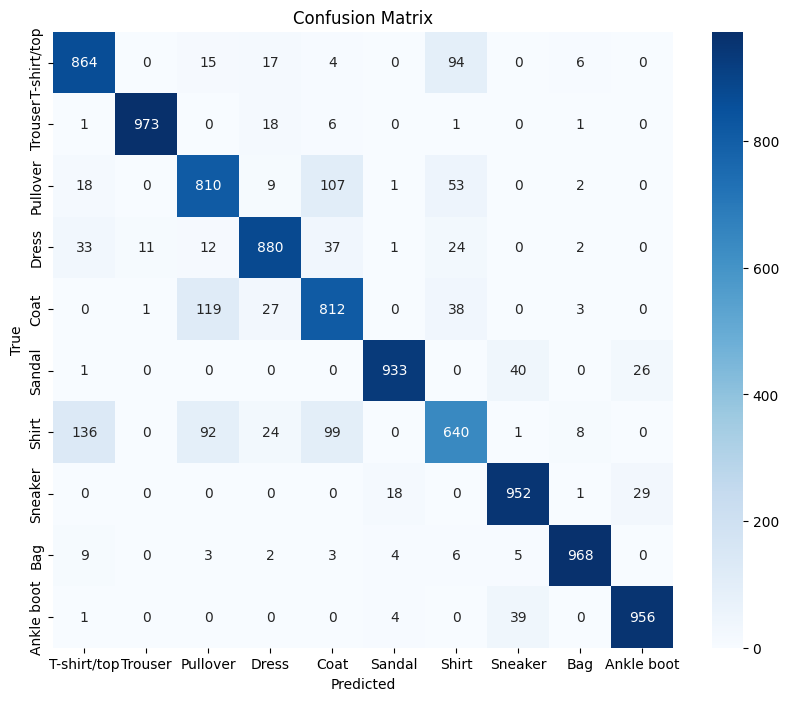

In [6]:
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=classes, yticklabels=classes)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

## Visualize Sample Predictions

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step


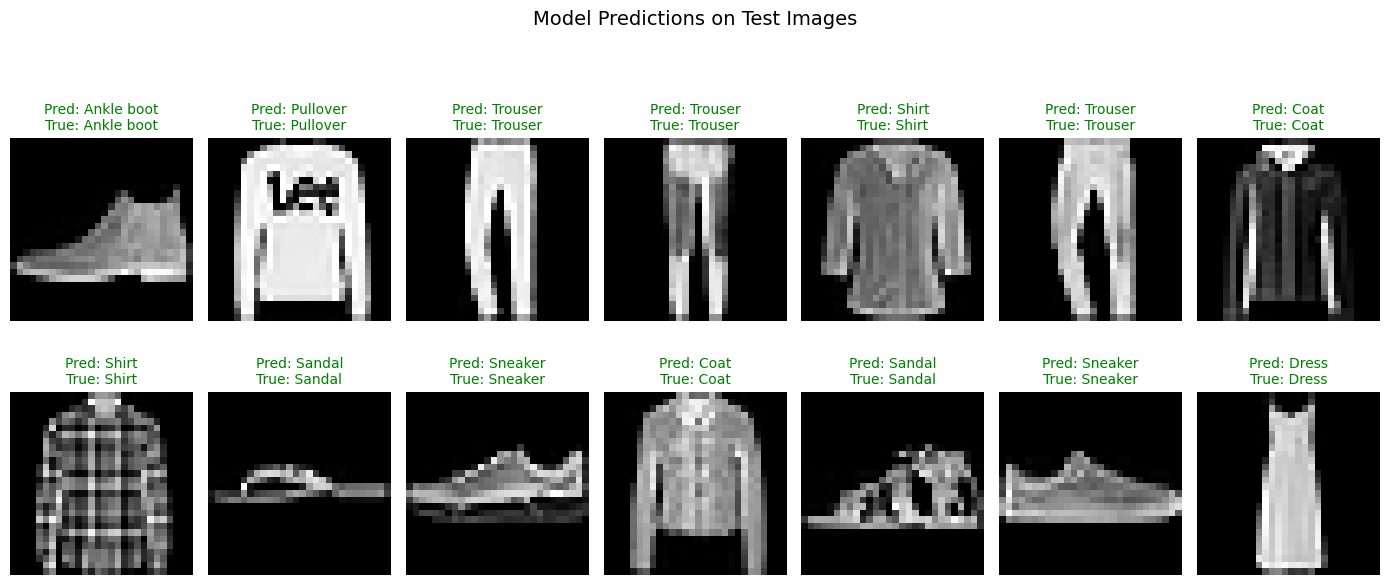

In [7]:
# Number of images to display
n_images = 14

# Get a batch of test data (just slice the numpy arrays)
images, labels = x_test[:n_images], y_test[:n_images]

# Get predictions
outputs = model.predict(images)
preds = np.argmax(outputs, axis=1)

# Create figure
plt.figure(figsize=(14, 6))
for i in range(n_images):
    plt.subplot(2, n_images // 2, i + 1)

    # Undo normalization: from [-1,1] → [0,1]
    img = images[i] * 0.5 + 0.5
    # .squeeze() is not needed, images are already (28, 28)

    # Plot grayscale image
    plt.imshow(img, cmap='gray')

    # Title shows prediction and true label
    color = 'green' if preds[i] == labels[i] else 'red'
    plt.title(f"Pred: {classes[preds[i]]}\nTrue: {classes[labels[i]]}",
              color=color, fontsize=10)
    plt.axis('off')

plt.suptitle("Model Predictions on Test Images", fontsize=14, y=1.05)
plt.tight_layout()
plt.show()

## Plot Training Progress

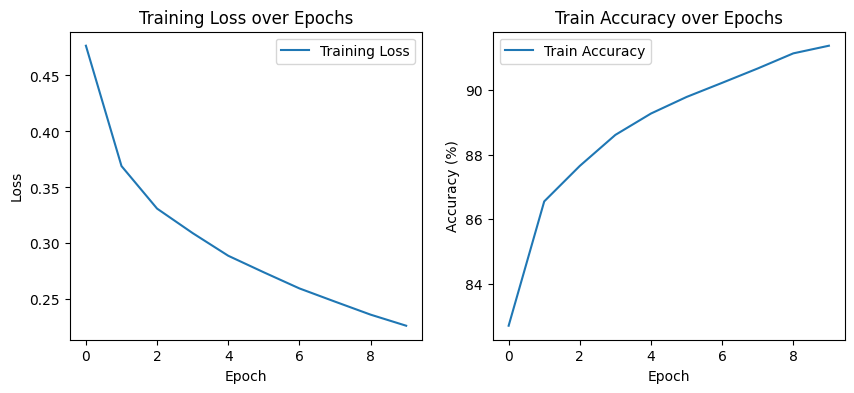

In [8]:
plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.plot(train_losses, label='Training Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Loss over Epochs')
plt.legend()

plt.subplot(1,2,2)
plt.plot(train_accuracies, label='Train Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.title('Train Accuracy over Epochs')
plt.legend()
plt.show()

## Conclusion

The fully connected neural network achieved a final test accuracy of 87.88%, surpassing the target benchmark of 85%. The training loss consistently decreased across epochs, indicating effective learning and stable convergence. From the confusion matrix, the model performed particularly well on classes like Sneaker, Bag, and Trouser, while showing some confusion between visually similar categories such as Shirt, T-shirt/top, and Coat. Overall, the model demonstrates strong classification performance on the Fashion-MNIST dataset, effectively distinguishing most clothing types using a simple multilayer perceptron architecture.